In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
df = pd.read_csv("D:\churnsense\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## * EDA

In [4]:
print(f"Shape:{df.shape}") 

Shape:(7043, 21)


In [5]:
print(f"Data types:\n{df.dtypes}")

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [6]:
print(f"Null values:\n{df.isnull().sum()}")

Null values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
print(f"Duplicates:{df.duplicated().sum()}")

Duplicates:0


In [8]:
with pd.option_context('display.max_columns', None):
    display(df.head())


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors='coerce')

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

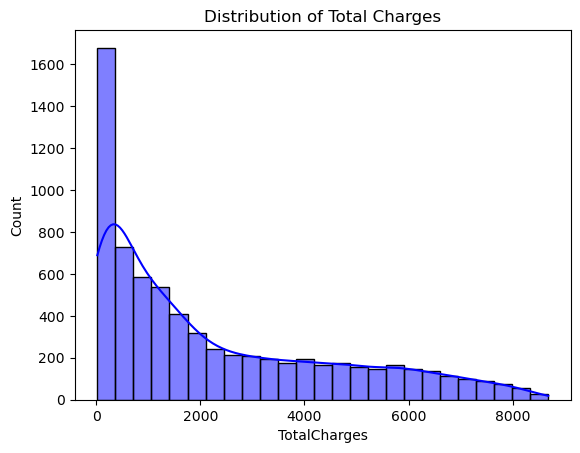

In [11]:

target_col = df["TotalCharges"]

sns.histplot(target_col.dropna(), kde=True, color='blue')
plt.title('Distribution of Total Charges')
plt.show()


In [12]:
print(f"Mean:{df["TotalCharges"].mean()}\nMedian:{df["TotalCharges"].median()}")

Mean:2283.3004408418656
Median:1397.475


In [13]:
df["TotalCharges"].skew()

np.float64(0.961642499724251)

In [14]:
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

- **% of Churned customers**

In [17]:
print(f"Churn % :{(((df["Churn"].value_counts()[1:2])/df.shape[0])*100).iloc[0]}")

Churn % :26.536987079369588


<function matplotlib.pyplot.show(close=None, block=None)>

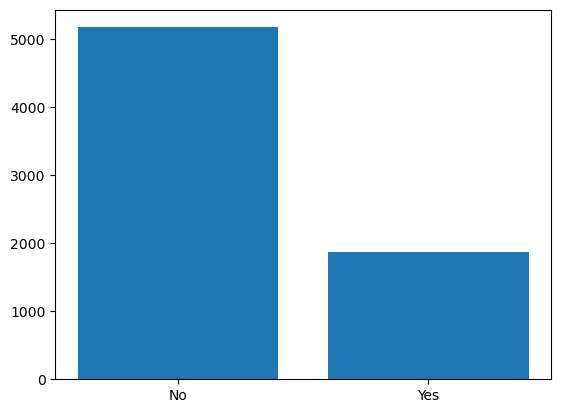

In [18]:
plt.bar(df["Churn"].value_counts().index,df["Churn"].value_counts())
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

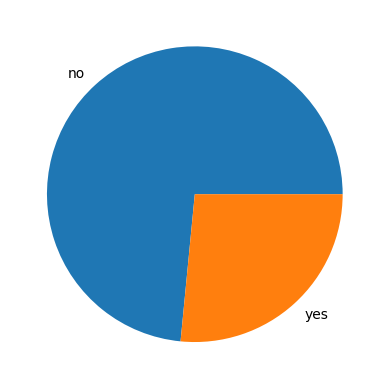

In [19]:
plt.pie(df["Churn"].value_counts(),labels = ['no','yes'])
plt.show

In [20]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [21]:
col = list(df.columns)

In [22]:
for i in col:
    if df[i].dtype == object and i != 'customerID':
        print(f"{df.groupby(i)['Churn'].apply(lambda x: (x=='Yes').mean()*100)}\n")
    

gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64

Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64

Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64

PhoneService
No     24.926686
Yes    26.709637
Name: Churn, dtype: float64

MultipleLines
No                  25.044248
No phone service    24.926686
Yes                 28.609896
Name: Churn, dtype: float64

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64

OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn, dtype: float64

OnlineBackup
No                     39.928756
No internet service     7.404980
Yes                    21.531494
Name: Churn, dtype: float64

DeviceProtection
No                     39.127625
No internet service     7.404980
Yes                    22.502064
Name: Churn, dtype: float64

TechSupport
No       

In [23]:
type(df['Contract'].dtype)

numpy.dtypes.ObjectDType

In [24]:
num_cols = df.select_dtypes(include = ['int','float']).columns.to_list()

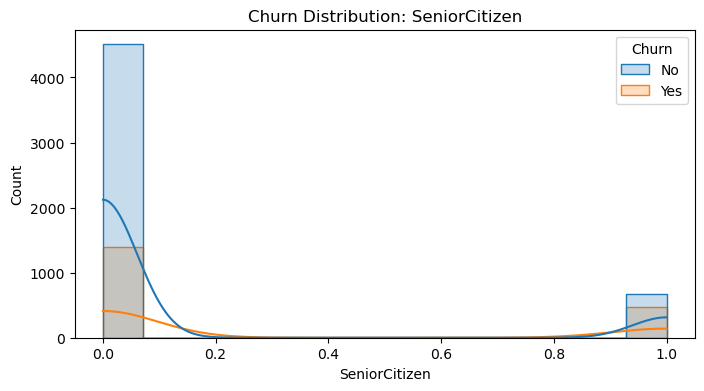

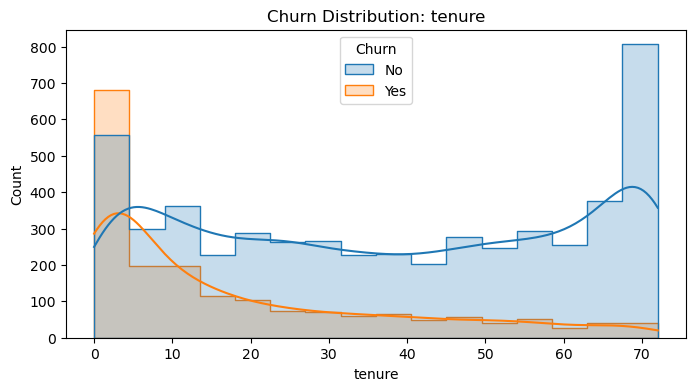

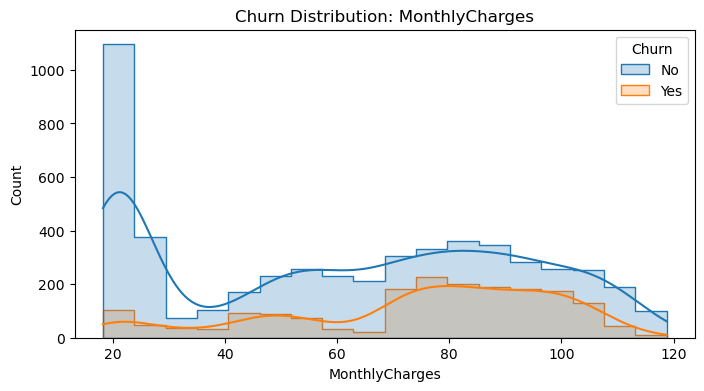

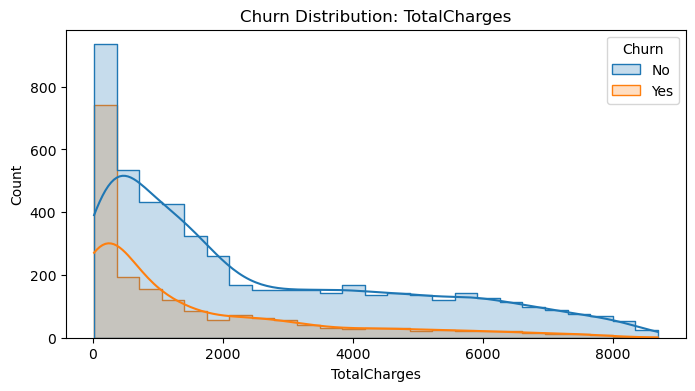

In [25]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element="step")
    plt.title(f'Churn Distribution: {col}')
    plt.show()

In [26]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [27]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [28]:
df.select_dtypes(include=['int','float']).corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.102652,0.150889
tenure,0.016567,1.000000,0.247900,0.825464,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.650864,0.193356
TotalCharges,0.102652,0.825464,0.650864,1.000000,-0.199037
Churn,0.150889,-0.352229,0.193356,-0.199037,1.000000


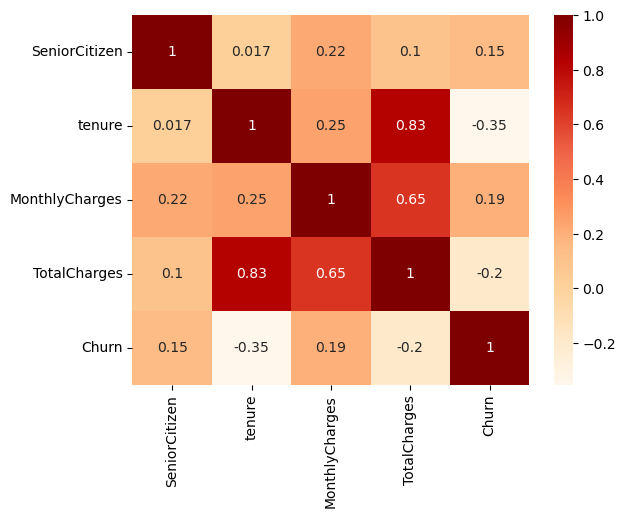

In [29]:
sns.heatmap(data = df.select_dtypes(include=['int','float']).corr(),annot=True,cmap="OrRd")
plt.show()

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.select_dtypes(include = 'number').skew().sort_values(ascending = False)

SeniorCitizen     1.833633
Churn             1.063031
TotalCharges      0.963789
tenure            0.239540
MonthlyCharges   -0.220524
dtype: float64

In [32]:
df.drop("customerID",axis = 1,inplace = True)


In [33]:
x = df.drop(columns = "Churn")
y = df["Churn"]


In [50]:
X = x.copy()

In [51]:
Y = y.copy()

In [34]:
x_linr = x.copy()

In [35]:
x_linr.select_dtypes(include = 'number').skew().sort_values(ascending = False)

SeniorCitizen     1.833633
TotalCharges      0.963789
tenure            0.239540
MonthlyCharges   -0.220524
dtype: float64

### **Skewness Treatment**

In [36]:
# "TotalCharges Skewness Treatment"
from sklearn.preprocessing import PowerTransformer

In [37]:
pt = PowerTransformer(method='yeo-johnson')

In [38]:
x_linr['TotalCharges'] = pt.fit_transform(x_linr[['TotalCharges']])

In [39]:
print(f"New skewness for Totalcharges: {x_linr['TotalCharges'].skew()}")

New skewness for Totalcharges: -0.14433732998312213


In [40]:
df["SeniorCitizen"].unique()

array([0, 1])

In [41]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [43]:
for i in x.select_dtypes(include = 'object').columns.to_list():
    print(f"{x[i].value_counts()}\n")

gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

StreamingTV
No                 

In [44]:
from sklearn.preprocessing import LabelEncoder

# 1. Create a copy of your features
x_label = x.copy()

# 2. Initialize the LabelEncoder
le = LabelEncoder()

# 3. Identify categorical columns
categorical_cols = x_label.select_dtypes(include=['object']).columns

# 4. Apply Label Encoding to each column
for col in categorical_cols:
    x_label[col] = le.fit_transform(x_label[col])

# Check the results
#x_label.head()

In [49]:
x_label.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [48]:

# 1. This identifies all your text columns automatically


# 2. Perform One-Hot Encoding
# This will turn 'Contract' (3 categories) into 'Contract_One year' and 'Contract_Two year'
x_encoded = pd.get_dummies(x, columns=list(categorical_cols), drop_first=True)

# 3. Modern pandas returns True/False; we need 1/0 for SMOTE and modeling
#x_encoded = x_encoded.astype(int)

# Check how many new columns were created
print(f"New column count: {x_encoded.shape[1]}")
x_encoded.head()

New column count: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


### **Splitting into train and test**

In [54]:
X_train, X_test, y_train, y_test = train_test_split(x_label, y, test_size=0.25, random_state=42, stratify=y)

In [55]:
print(f"Before SMOTE: {Counter(y_train)}")

Before SMOTE: Counter({0: 3880, 1: 1402})


In [56]:
# 3. Apply SMOTE only to the Training Set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [57]:
print(f"After SMOTE: {Counter(y_train_res)}")

After SMOTE: Counter({0: 3880, 1: 3880})


In [58]:
X_train_res

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,1,72,0,1,0,0,2,0,2,2,2,2,0,1,53.650000,3784.000000
1,0,0,0,0,4,1,0,0,0,0,0,0,0,0,0,1,3,46.000000,193.600000
2,1,0,0,1,56,1,0,2,1,1,1,1,1,1,1,1,3,21.200000,1238.650000
3,1,0,0,0,56,1,2,1,0,2,0,2,0,2,0,1,2,94.450000,5124.600000
4,0,0,0,0,9,1,0,1,0,0,0,0,0,2,0,1,2,79.550000,723.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7755,0,0,0,0,16,1,1,0,0,0,2,2,1,2,0,1,1,87.443389,1425.944854
7756,0,0,0,0,16,0,0,0,0,1,0,1,0,0,0,1,2,51.378062,823.494246
7757,0,0,0,0,8,0,0,0,0,0,1,0,0,0,0,0,1,27.355760,221.779104
7758,0,1,0,0,26,0,0,0,0,0,0,0,0,1,0,0,0,36.554437,1031.980745


In [59]:
x_label

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60
